In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [ ]:
class SMALong_Strategy_Tearsheet(): 
    def __init__(self, symbol, SMA_S, SMA_L, start, end, RiskFreeRate):
        self.symbol = symbol
        self.SMA_S = SMA_S
        self.SMA_L = SMA_L
        self.start = start
        self.end = end
        self.RFR = RiskFreeRate
        self.results = None
        self.get_data()

    def get_data(self): 
        df = yf.download(self.symbol, start = self.start, end = self.end)
        data = df[["Close"]].copy()
        data["returns"] = np.log(data.Close.div(data.Close.shift(1)))
        data["SMA_S"] = data.Close.rolling(self.SMA_S).mean()
        data["SMA_L"] = data.Close.rolling(self.SMA_L).mean()
        data.dropna(inplace = True)
        self.data2 = data

        return data

    def performance_metrics(self):
        data = self.data2.copy().dropna()
        data["position"] = np.where(data["SMA_S"] > data["SMA_L"], 1, 0) # This determines if you are gonna go long or short 
        data["strategy"] = data["returns"]*data["position"].shift(1)
        data.dropna(inplace = True)
        data["returnsBH"] = data["returns"].cumsum().apply(np.exp) # This is where you could try diff benchmark 
        data["returnsstrategy"] = data["strategy"].cumsum().apply(np.exp)

        self.results = data
        self.strat_returns = data["strategy"]
        self.bh_returns = data["returns"]
        self.strat_cum = data["returnsstrategy"]
        self.bh_cum = data["returnsBH"]

        
        perf = data["returnsstrategy"].iloc[-1]
        bh_perf = data["returnsBH"].iloc[-1]
        outperf = perf - data["returnsBH"].iloc[-1]
        std_strat = (data["strategy"].std() * np.sqrt(252)) * 100

        return print("Performance: ", round(perf,4), 
                "\nOutperformance: ", round(outperf,4),
                "\nBenchmark Performance: ", round(bh_perf,4))

    def ratios(self):  
        log_data = (self.strat_returns["strategy"] 
            if isinstance(self.strat_returns, pd.DataFrame) 
            else self.strat_returns
        ).dropna()

        simple_returns = np.exp(log_data) - 1.0

        daily_rf = (1.0 + self.RFR) ** (1.0/252.0) - 1.0  
        # The Risk Free Rate is set automatically, but could be calculated 
        # from various short-term government securities such as the 3-month Treasury bill rate or data sources
        excess_returns = simple_returns - daily_rf
        daily_mean_excess = excess_returns.mean()

        daily_std = simple_returns.std()
        downside_returns = np.minimum(0, excess_returns)
        downside_std = np.sqrt(np.mean(downside_returns**2))

        sharpe = np.divide(daily_mean_excess, daily_std) * np.sqrt(252) # Risk-adjusted return 

        sortino = np.divide(daily_mean_excess * 252, downside_std * np.sqrt(252)) # Downside risk-adjusted return

        return print("Annualized Sharpe Ratio: ", round(sharpe, 4)
                    ,"\nAnnualized Sortino Ratio: ", round(sortino, 4))

    def max_drawdown(self):
        data = self.strat_cum.copy().dropna().squeeze()
        close = data if isinstance(data, pd.Series) else data.squeeze()

        local_max = close.cummax()
        # Calculate drawdown at each point and find the worst one
        drawdown = (close - local_max) / local_max
        mdd = drawdown.min() * 100 # Worst Peak to Trough of the trading strategy  

        mdd_val = mdd.item()
        print(f"Maximum Drawdown: {mdd_val:.2f}%")

    def CAGR(self):
        data = self.strat_cum.copy().dropna()

        start_price = 1.0
        end_price = data.iloc[-1].item()

        days = (data.index[-1] - data.index[0]).days
        years = days / 365.25

        cagr = ((end_price / start_price) ** (1.0 / years) - 1.0) * 100 # Anualized Growth 

        return print(f"Yearly Percentage Return (CAGR): {cagr:.2f}%")

    def beta(self):
        data = self.strat_returns.copy().dropna()
        data_bench = self.bh_returns.copy().dropna()

        Covariance = data.cov(data_bench)
        Variance = data_bench.var()
        beta = Covariance / Variance # Market Exposure vs Benchmark

        return print(f"Beta: {beta:.4f}")

    def volatility(self):
        data = self.strat_returns.copy().dropna().squeeze()
        daily_std = data.std()
        annualized_vol = daily_std * np.sqrt(252) * 100 # Annualized Standard Deviation

        return print(f"Annualized Volatility: {annualized_vol:.2f}%")

    def CAPM_alpha(self): # May want this to be a precentage 
        data = self.strat_returns.copy().dropna()
        data_bench = self.bh_returns.copy().dropna()

        Covariance = data.cov(data_bench)
        Variance = data_bench.var()
        beta = Covariance / Variance

        rfr_pct = self.RFR * 100

        start_price = data.iloc[0].item()
        end_price = data.iloc[-1].item()
        days = (data.index[-1] - data.index[0]).days
        years = days / 365.25
        cagr = ((end_price / start_price) ** (1 / years) - 1) * 100

        benchmark_cagr = ((data_bench.iloc[-1].item() / data_bench.iloc[0].item()) ** (1 / years) - 1) * 100

        alpha = cagr - (rfr_pct + beta * (benchmark_cagr - rfr_pct))

        return print(f"Annualized Alpha (CAPM-Adjusted): {alpha:.4f}")

    def simple_alpha(self): # May want this to be a precentage
        data = self.strat_cum.copy().dropna()
        data_bench = self.bh_cum.copy().dropna()

        strat_start_price = 1.0
        strat_end_price = data.iloc[-1].item()
        bench_start_price = 1.0
        bench_end_price = (data_bench.iloc[-1].item() / data_bench.iloc[0].item())

        days = (data.index[-1] - data.index[0]).days
        years = days / 365.25

        cagr = ((strat_end_price / strat_start_price) ** (1.0 / years) - 1.0) * 100
        benchmark_cagr = ((bench_end_price / bench_start_price) ** (1.0 / years) - 1.0) * 100

        alpha = cagr - benchmark_cagr

        return print(f"Annualized Simple Alpha: {alpha:.4f}%")

    def equity_curve(self): 
        title = "{}] SMA_S={} | SMA_L{}".format(self.symbol, self.SMA_S, self.SMA_L)
        self.results[["returnsBH", "returnsstrategy"]].plot(title = title, figsize = (12,8))
        plt.show()

In [4]:
tester = SMALong_Strategy_Tearsheet("SPY", 50, 100, "2000-01-01", "2020-01-01", 0.03)

[*********************100%***********************]  1 of 1 completed


In [5]:
tester.performance_metrics()

Performance:  3.5387 
Outperformance:  0.2089 
Benchmark Performance:  3.3299


In [6]:
tester.max_drawdown()

Maximum Drawdown: -19.40%


In [7]:
tester.CAGR()

Yearly Percentage Return (CAGR): 6.66%


In [8]:
tester.beta()

Beta: 0.3577


In [9]:
tester.simple_alpha()

Annualized Simple Alpha: 0.2366%


In [10]:
tester.CAPM_alpha()

Annualized Alpha (CAPM-Adjusted): -8.7971+9.2732j


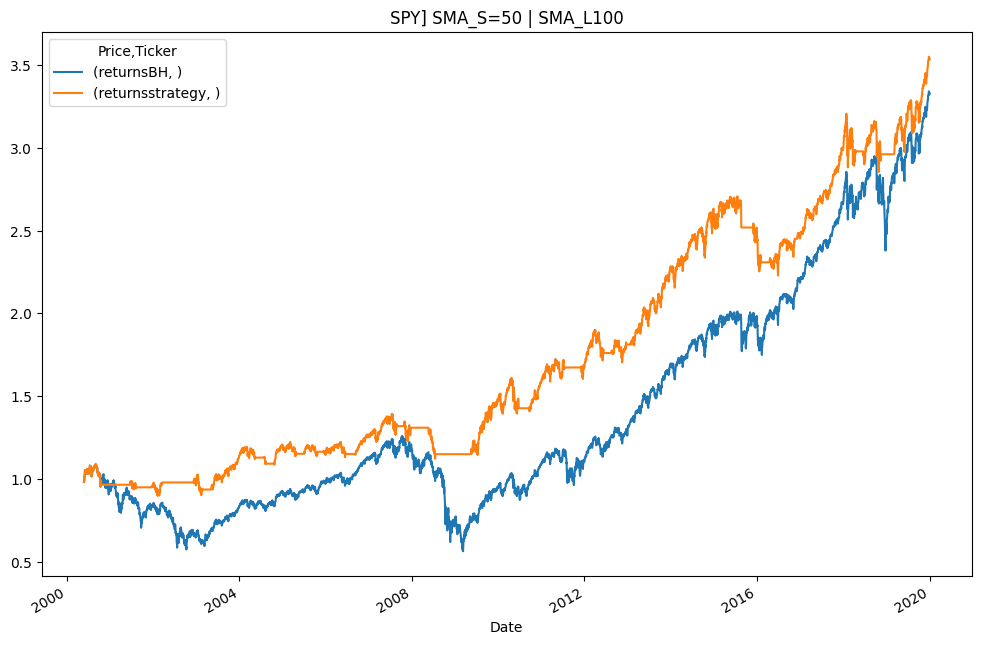

In [12]:
tester.equity_curve()